In [42]:
!pip install xgboost -q

In [43]:
# Import Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

In [44]:
# Load Dataset
df = pd.read_csv("Country-data.csv")

df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [45]:
# Dataset Information
print("Shape:", df.shape)

df.info()

df.describe()

Shape: (167, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


In [46]:
# Missing Values
df.isnull().sum()
# Duplicate Values
df.duplicated().sum()

np.int64(0)

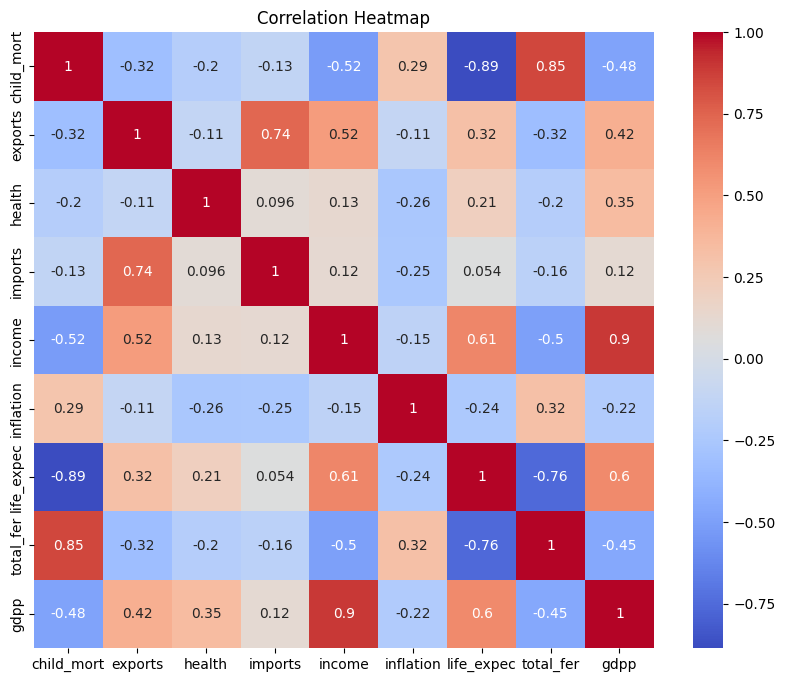

In [47]:
# Correlation Heatmap
plt.figure(figsize=(10,8))

sns.heatmap(
    df.drop('country',axis=1).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

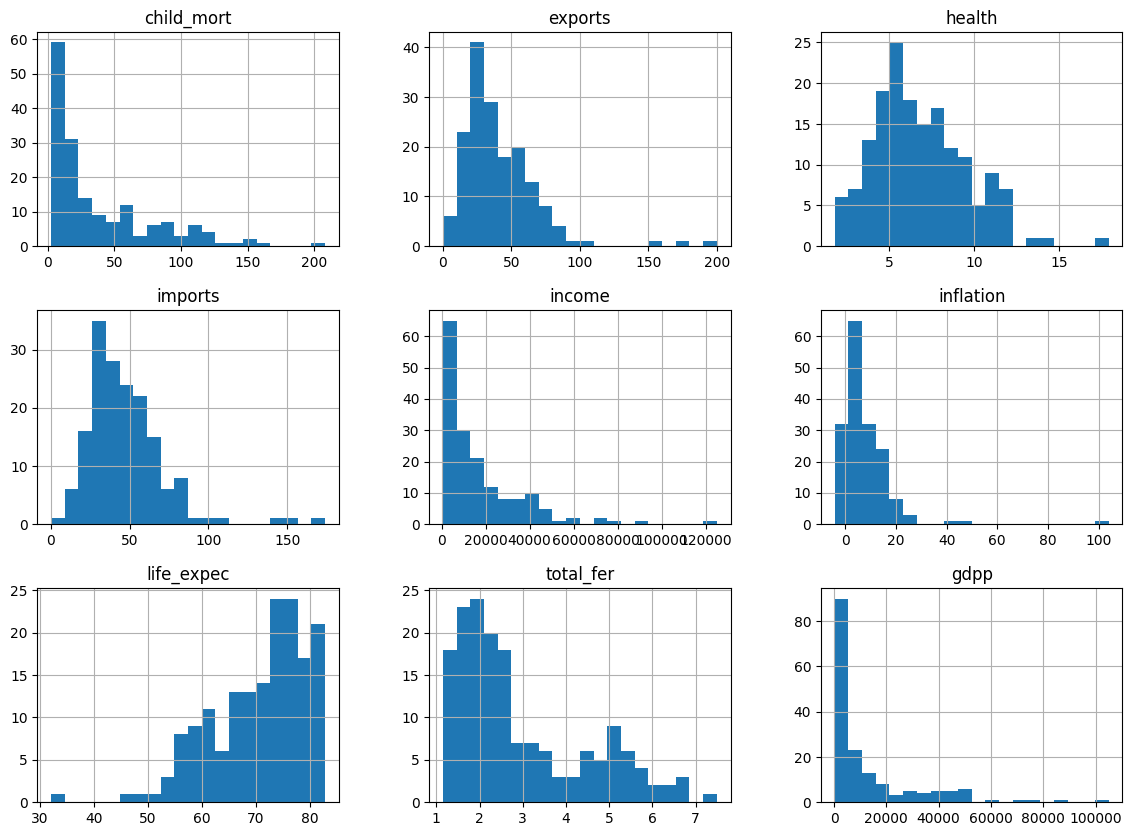

In [48]:
# Histograms
df.drop('country',axis=1).hist(
    figsize=(14,10),
    bins=20
)

plt.show()

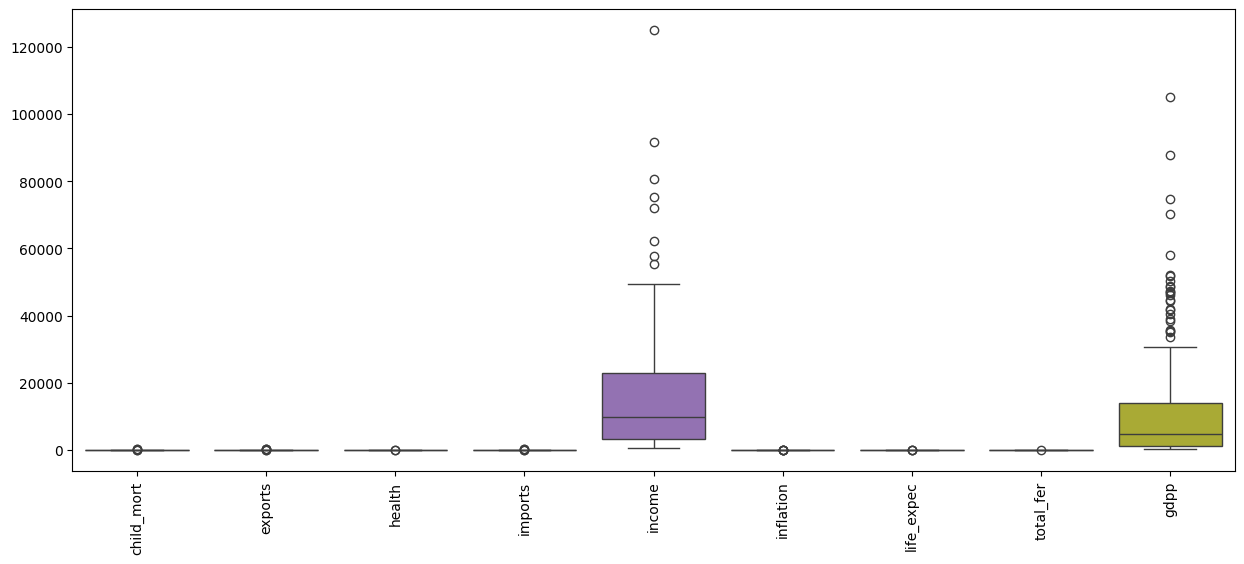

In [49]:
# Boxplots
plt.figure(figsize=(15,6))

sns.boxplot(data=df.drop('country',axis=1))

plt.xticks(rotation=90)

plt.show()

In [50]:
# Feature Scaling
X = df.drop('country',axis=1)

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [51]:
# PCA
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print(
    "Explained Variance Ratio:",
    pca.explained_variance_ratio_
)

Explained Variance Ratio: [0.4595174  0.17181626]


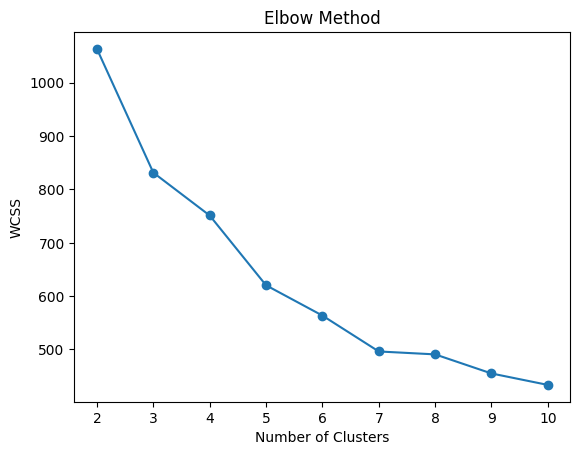

In [52]:
# Elbow Method
wcss = []

for i in range(2,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

plt.plot(range(2,11),wcss,marker='o')

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.show()

In [53]:
# K-Means Clustering
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Cluster
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,2
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,0
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,0
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,2
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,0


In [54]:
# Silhouette Score
score = silhouette_score(
    X_scaled,
    clusters
)

print("Silhouette Score:",score)

Silhouette Score: 0.285600988953231


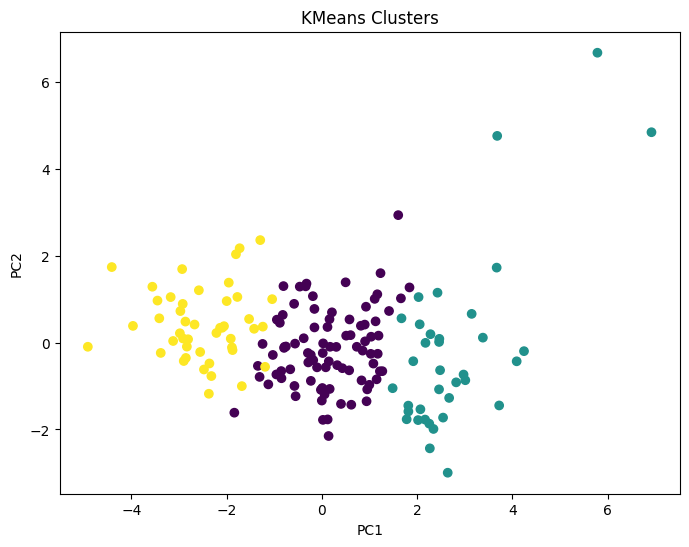

In [55]:
# PCA Cluster Visualization
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters,
    cmap='viridis'
)

plt.title("KMeans Clusters")

plt.xlabel("PC1")

plt.ylabel("PC2")

plt.show()

In [57]:
# DBSCAN
dbscan = DBSCAN(
    eps=1.5,
    min_samples=5
)

db_clusters = dbscan.fit_predict(X_scaled)

print(
    "Unique DBSCAN Clusters:",
    np.unique(db_clusters)
)

Unique DBSCAN Clusters: [-1  0]


In [58]:
# Create Target

# Using K-Means cluster labels.

X = df.drop(
    ['country','Cluster'],
    axis=1
)

y = df['Cluster']

In [59]:
# Train-Test Split
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [60]:
# Logistic Regression
lr = LogisticRegression()

lr.fit(
    X_train,
    y_train
)

lr_pred = lr.predict(X_test)

print(
    "Logistic Regression Accuracy:",
    accuracy_score(y_test,lr_pred)
)

Logistic Regression Accuracy: 1.0


In [61]:
# Random Forest
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

rf_pred = rf.predict(X_test)

print(
    "Random Forest Accuracy:",
    accuracy_score(y_test,rf_pred)
)

Random Forest Accuracy: 1.0


In [62]:
# XGBoost
xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

xgb.fit(
    X_train,
    y_train
)

xgb_pred = xgb.predict(X_test)

print(
    "XGBoost Accuracy:",
    accuracy_score(y_test,xgb_pred)
)

XGBoost Accuracy: 1.0


In [63]:
# Model Comparison
results = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy":[
        accuracy_score(y_test,lr_pred),
        accuracy_score(y_test,rf_pred),
        accuracy_score(y_test,xgb_pred)
    ]
})

results

,Model,Accuracy
0,Logistic Regression,1.0
1,Random Forest,1.0
2,XGBoost,1.0


In [64]:
# Classification Report
print(
    classification_report(
        y_test,
        xgb_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00         8
           2       1.00      1.00      1.00         6

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



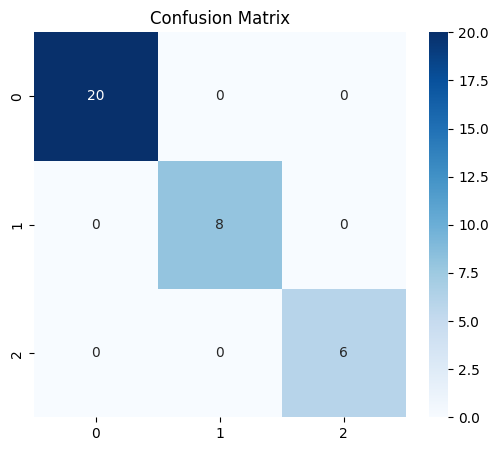

In [65]:
# Confusion Matrix
cm = confusion_matrix(
    y_test,
    xgb_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.show()

In [66]:
# Feature Importance
importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":rf.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
0,child_mort,0.297915
8,gdpp,0.207588
4,income,0.166506
7,total_fer,0.137901
6,life_expec,0.128936
2,health,0.029240
1,exports,0.013228
5,inflation,0.011604
3,imports,0.007082


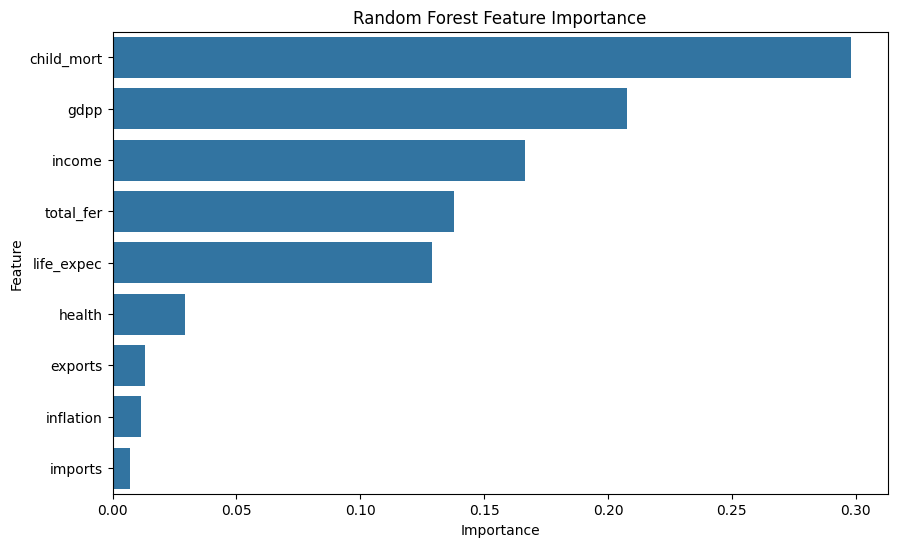

In [67]:
# Feature Importance Graph
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title(
    "Random Forest Feature Importance"
)

plt.show()

In [68]:
# Final Conclusion
best_model = results.loc[
    results['Accuracy'].idxmax()
]

print(
    "Best Model:",
    best_model['Model']
)

print(
    "Accuracy:",
    best_model['Accuracy']
)

Best Model: Logistic Regression
Accuracy: 1.0
